In [1]:
using Pkg
Pkg.activate(joinpath(@__FILE__, "..", ".."))
Pkg.instantiate()
using Revise
import HybridDynamics as HD
import Plots as plt

  Activating project at `c:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl`
Precompiling packages...
    858.1 ms  ? HybridDynamics

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.


LINEAR AND AFFINE EXAMPLES

Currently this works for my intialization. Double check yourselves!

In [2]:
A = [-.1 1.0; -1.0 -0.1]
λ = [1.0, 0.0]
a = 0.0
C = [-.5 0.0 ; 0.0 1.0] 
x0 = [1.0, 0.0]
tspan = (0.0, 5.0)
b = [0.0, 0.0]
κ = [0.0, 0.0]

2-element Vector{Float64}:
 0.0
 0.0

Edit any of the above to test different systems. Of course if you want purely linear just make the affine elements 0.

In [3]:
#Putting NaNs when jumps occur to prevent Plots from drawing continuous lines. 
function get_rid_of_jump_lines(sol)
    x1 = Float64[]
    x2 = Float64[]

    for i in 1:length(sol.x)
        push!(x1, sol.x[i][1])
        push!(x2, sol.x[i][2])
        # If the time doesn't advance, a jump occurred
        if i < length(sol.t) && sol.t[i] == sol.t[i+1]
            push!(x1, NaN)
            push!(x2, NaN)
        end
    end
    return x1, x2
end

get_rid_of_jump_lines (generic function with 1 method)

Above is the function I used in the Demos to get rid of the lines that connect jumps and reset points. Unsure if this is best way but does a great job for now

In [4]:
function add_guard!(p, λ, a=0.0)
    if abs(λ[2]) < 1e-10
        plt.vline!(p, [-a / λ[1]], label="Guard", color=:black, alpha=0.3, linewidth=2)
    else
        xl = plt.xlims(p)
        x_vals = [xl[1], xl[2]]
        y_vals = @. (-a - λ[1] * x_vals) / λ[2]
        plt.plot!(p, x_vals, y_vals, label="Guard", color=:black, alpha=0.3, linewidth=2)
        plt.xlims!(p, xl) # Lock the limits so the guard doesn't stretch the plot
    end
end;

This function is to make the guard adapt to what you input above in parameters. Might be overengineered...

Below is the Affine system workflow. It SHOULD work with other solvers and locators. Tested most but not all. 

Solving Affine System...


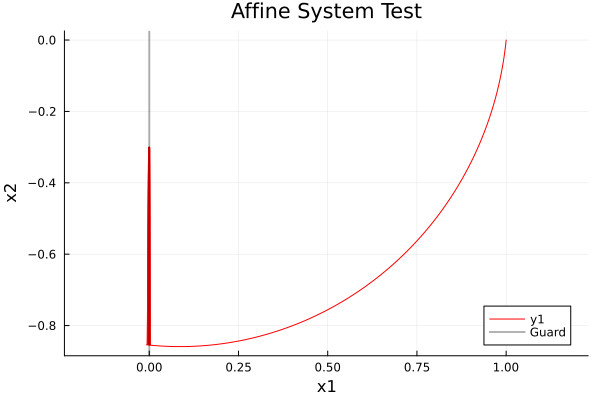

┌ Info: Zeno contraction detected. count: 1
└ @ HybridDynamics c:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\src\Systems\General.jl:55
┌ Info: Zeno contraction detected. count: 1
└ @ HybridDynamics c:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\src\Systems\General.jl:55
┌ Info: Zeno contraction detected. count: 2
└ @ HybridDynamics c:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\src\Systems\General.jl:55
┌ Info: Zeno contraction detected. count: 3
└ @ HybridDynamics c:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\src\Systems\General.jl:55
┌ Info: Zeno contraction detected. count: 4
└ @ HybridDynamics c:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\src\Systems\General.jl:55
┌ Info: Zeno contraction detected. count: 5
└ @ HybridDynamics c:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\src\Systems\General.jl:55
┌ Warning: Zeno Accumulation Point Reached at t = 4.999935619908562. Terminating.
└ @ HybridDynamics c:\Users\david\Desktop\Progra

In [5]:
# Build and Solve
sys_affine = HD.AffineSystem(A, b, λ, a, C, κ)
prob_affine = HD.prob(sys_affine, x0, tspan)

println("Solving Affine System...")
sol_affine = HD.solve(prob_affine, HD.RK4(); event_method = HD.LinearLocator())

# Plot trajectories
p_affine = plt.plot(title="Affine System Test", xlabel="x1", ylabel="x2", grid=true, aspect_ratio=:equal)

x1_aff, x2_aff = get_rid_of_jump_lines(sol_affine)
plt.plot!(p_affine, x1_aff, x2_aff, color=:red)

#add the guard based on Cell 1's λ and Cell 2's a
add_guard!(p_affine, λ, a)

plt.display(p_affine)

Solving Linear System...


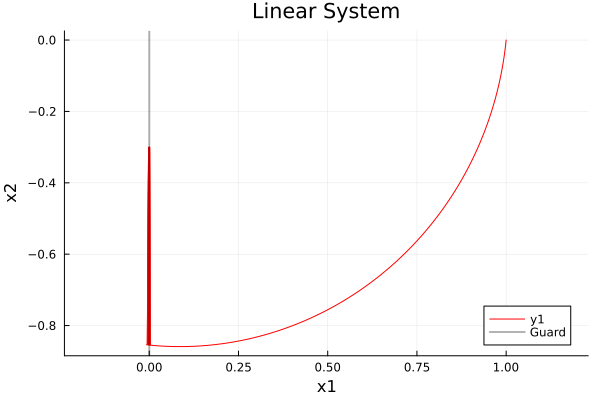

┌ Info: Zeno contraction detected. count: 1
└ @ HybridDynamics c:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\src\Systems\General.jl:55
┌ Info: Zeno contraction detected. count: 1
└ @ HybridDynamics c:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\src\Systems\General.jl:55
┌ Info: Zeno contraction detected. count: 2
└ @ HybridDynamics c:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\src\Systems\General.jl:55
┌ Info: Zeno contraction detected. count: 3
└ @ HybridDynamics c:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\src\Systems\General.jl:55
┌ Info: Zeno contraction detected. count: 4
└ @ HybridDynamics c:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\src\Systems\General.jl:55
┌ Info: Zeno contraction detected. count: 5
└ @ HybridDynamics c:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\src\Systems\General.jl:55
┌ Warning: Zeno Accumulation Point Reached at t = 4.999935619908562. Terminating.
└ @ HybridDynamics c:\Users\david\Desktop\Progra

In [6]:
# Build system using shared parameters
sys_linear = HD.LinearSystem(A, λ, C)
prob_linear = HD.prob(sys_linear, x0, tspan)

println("Solving Linear System...")

# Compare Solvers
sol_linear = HD.solve(prob_linear, HD.RK4())

# Plot trajectories
p_linear = plt.plot(title="Linear System", xlabel="x1", ylabel="x2", aspect_ratio=:equal)

x1_linear, x2_linear = get_rid_of_jump_lines(sol_linear)
plt.plot!(p_linear, x1_linear, x2_linear, color=:red)

# Dynamically add the guard based input
add_guard!(p_linear, λ, 0.0)

display(p_linear)

You will notice Zeno works-ish. I got it to not blow up on itself but much more testing is needed before I can call it good. I also dont know of a fix for the Linear "Zeno" yet. As Linear cant have Zeno im thinking of how to make that reflected here. I may need to refresh myself with that proof though. 

Below is me testing the actual data. Doesnt need to be in final notebook but very useful so I keep it!

In [7]:
println("Time | State AFFINE")
for i in 1:length(sol_affine.t)
    println(sol_affine.t[i], " | ", sol_affine.x[i])
end

Time | State AFFINE
0.0 | [1.0, 0.0]
0.01 | [0.9989505502250416, -0.009989838498333336]
0.02 | [0.9978024049216907, -0.019958709329138777]
0.03 | [0.9965558771295595, -0.029905648544541148]
0.04 | [0.9952112891894246, -0.03982969633549532]
0.05 | [0.9937689726921195, -0.049729897120359835]
0.060000000000000005 | [0.9922292684265961, -0.05960529963286708]
0.07 | [0.9905925263271617, -0.06945495700948218]
0.08 | [0.9888591054198989, -0.07927792687614318]
0.09 | [0.987029373768275, -0.08907327143437502]
0.09999999999999999 | [0.985103708417949, -0.09884005754676957]
0.10999999999999999 | [0.983082495340781, -0.1085773568218248]
0.11999999999999998 | [0.9809661293780542, -0.1182842456981355]
0.12999999999999998 | [0.9787550141829151, -0.1279598055279284]
0.13999999999999999 | [0.9764495621620394, -0.13760312265993468]
0.15 | [0.9740501944165312, -0.1472132885215927]
0.16 | [0.9715573406820633, -0.15678939970057418]
0.17 | [0.968971439268266, -0.1663305580256266]
0.18000000000000002 | [0.96

In [8]:
println("Time | State LINEAR")
for i in 1:length(sol_linear.t)
    println(sol_linear.t[i], " | ", sol_linear.x[i])
end

Time | State LINEAR
0.0 | [1.0, 0.0]
0.01 | [0.9989505502250416, -0.009989838498333336]
0.02 | [0.9978024049216907, -0.019958709329138777]
0.03 | [0.9965558771295595, -0.029905648544541148]
0.04 | [0.9952112891894246, -0.03982969633549532]
0.05 | [0.9937689726921195, -0.049729897120359835]
0.060000000000000005 | [0.9922292684265961, -0.05960529963286708]
0.07 | [0.9905925263271617, -0.06945495700948218]
0.08 | [0.9888591054198989, -0.07927792687614318]
0.09 | [0.987029373768275, -0.08907327143437502]
0.09999999999999999 | [0.985103708417949, -0.09884005754676957]
0.10999999999999999 | [0.983082495340781, -0.1085773568218248]
0.11999999999999998 | [0.9809661293780542, -0.1182842456981355]
0.12999999999999998 | [0.9787550141829151, -0.1279598055279284]
0.13999999999999999 | [0.9764495621620394, -0.13760312265993468]
0.15 | [0.9740501944165312, -0.1472132885215927]
0.16 | [0.9715573406820633, -0.15678939970057418]
0.17 | [0.968971439268266, -0.1663305580256266]
0.18000000000000002 | [0.96

GENERAL SYSTEMS EXAMPLES TESTING THINGS 

In [19]:
function get_rid_of_jump_line_bad(sol)
    x1 = Float64[]
    x2 = Float64[]
    ts = Float64[]
    for i in 1:length(sol.x)
        push!(x1, sol.x[i][1])
        push!(x2, sol.x[i][2])
        push!(ts, sol.t[i])
        
        # If the time doesn't advance, a jump occurred
        if i < length(sol.t) && sol.t[i] == sol.t[i+1]
            push!(x1, NaN)
            push!(x2, NaN)
            push!(ts, NaN)
        end
    end
    return ts, x1, x2
end

get_rid_of_jump_line_bad (generic function with 1 method)

In [ ]:
f(x, t) = [x[2], -sin(x[1])]
#Simple Pendulum hopefully, x1 angle and x2 velocity

f (generic function with 1 method)

In [31]:
h(x) = 1.0 - x[1]
#guard occurs when angle x1 is 1.0

h (generic function with 1 method)

In [32]:
function Δ(x)
    return [.5,0.0]
end
#Reset to [.5, 0.0] because

Δ (generic function with 1 method)

In [25]:
sys = HD.GeneralSystem(f, h, Δ)

HybridDynamics.GeneralSystem(Main.f, Main.h, Main.Δ)

In [26]:
prob = HD.prob(sys, [0.0, 2.0], (0.0, 5.0))

HybridDynamics.prob{HybridDynamics.GeneralSystem, Vector{Float64}, Tuple{Float64, Float64}}(HybridDynamics.GeneralSystem(Main.f, Main.h, Main.Δ), [0.0, 2.0], (0.0, 5.0))

In [27]:
sol = HD.solve(prob, HD.RK4())

┌ Info: Time step below minimum threshold 1.0e-6. Terminating.
└ @ HybridDynamics c:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\src\Systems\General.jl:119


HybridDynamics.GeneralSolution([0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.060000000000000005, 0.07, 0.08, 0.09  …  4.90999999999994, 4.9199999999999395, 4.929999999999939, 4.939999999999939, 4.949999999999939, 4.959999999999939, 4.9699999999999385, 4.979999999999938, 4.989999999999938, 4.999999999999938], [[0.0, 2.0], [0.019999666672222194, 1.999900004166436], [0.03999733359441589, 1.9996000666556353], [0.059991002016146336, 1.9991003373761373], [0.07997867518494685, 1.9984010659724296], [0.09995835934225852, 1.9975026015208106], [0.11992806471572443, 1.9964053921045652], [0.13988580650663596, 1.995109984269413], [0.15982960587134015, 1.9936170223604588], [0.17975749089543008, 1.9919272477421381]  …  [-0.1959254958649898, 0.4545005113367359], [-0.1913708314283705, 0.45642492683440256], [-0.1867971466924466, 0.4583045334727236], [-0.1822048908694836, 0.4601391073284471], [-0.17759451538654605, 0.46192842937484235], [-0.17296647383623895, 0.46367228554021933], [-0.16832122192686877, 0.4653704

In [28]:
ts, x1, x2 = get_rid_of_jump_line_bad(sol)

([0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.060000000000000005, 0.07, 0.08, 0.09  …  4.90999999999994, 4.9199999999999395, 4.929999999999939, 4.939999999999939, 4.949999999999939, 4.959999999999939, 4.9699999999999385, 4.979999999999938, 4.989999999999938, 4.999999999999938], [0.0, 0.019999666672222194, 0.03999733359441589, 0.059991002016146336, 0.07997867518494685, 0.09995835934225852, 0.11992806471572443, 0.13988580650663596, 0.15982960587134015, 0.17975749089543008  …  -0.1959254958649898, -0.1913708314283705, -0.1867971466924466, -0.1822048908694836, -0.17759451538654605, -0.17296647383623895, -0.16832122192686877, -0.16365921743203365, -0.15898092013965331, -0.1542867918004487], [2.0, 1.999900004166436, 1.9996000666556353, 1.9991003373761373, 1.9984010659724296, 1.9975026015208106, 1.9964053921045652, 1.995109984269413, 1.9936170223604588, 1.9919272477421381  …  0.4545005113367359, 0.45642492683440256, 0.4583045334727236, 0.4601391073284471, 0.46192842937484235, 0.46367228554021933, 0.

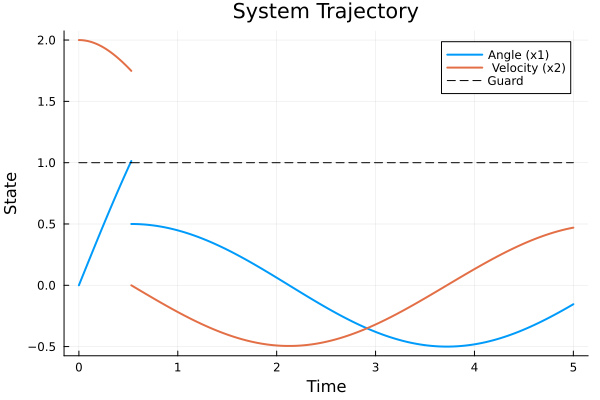

In [34]:
guard_line = [1.0 for _ in ts] #create threshold to plot on plot

#Plotting
p = plt.plot(ts, x1, label="Angle (x1)", lw=2, title="System Trajectory", xlabel="Time", ylabel="State")
plt.plot!(ts, x2, label=" Velocity (x2)", lw=2)
plt.plot!(ts, guard_line, label="Guard", linestyle=:dash, color=:black)

plt.display(p)

This doesnt work perfectly yet. Still figuring out the kinks. But here is a plot!
